# Julia vs Python — Derivative Comparison

Validates that the Python (JAX) and Julia (ForwardDiff) CyScat implementations
compute **identical matrix-valued derivatives** of $S_{21}$.

### What is compared
| Derivative | Python method | Julia method |
|---|---|---|
| $\partial S_{21}/\partial x_0$ | JAX `jvp` (forward-mode AD) | ForwardDiff (`Dual` on $x_0$) |
| $\partial S_{21}/\partial \lambda$ | JAX `jvp` (forward-mode AD) | ForwardDiff (`Dual` on $\lambda$) |
| $\partial S_{21}/\partial n$ | JAX `jacobian` | ForwardDiff (`Dual` on $n$, via $\varepsilon = n^2$) |

All three use exact automatic differentiation on both sides — agreement should be
at machine precision (~1e-12).

`smatrix()` builds JAX-traced spectral parameters ($k_0$, $k_{xs}$, $k_{ys}$, Angles)
internally from `lambda_wave`, so the full pipeline is differentiable w.r.t. $\lambda$.

### Workflow
1. Run all cells in order — generates `shared_params.npz` then calls Julia.
2. Requires Julia with the CyScat package (`../../../../julia/`).

In [1]:
import os
os.environ["JAX_ENABLE_X64"] = "1"   # must be set before JAX initializes

import sys, subprocess, time
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm, svd

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

sys.path.insert(0, '../..')

from Scattering_Code.smatrix_parameters import smatrix_parameters
from Scattering_Code.jax.smatrix import smatrix, smatrix_precompute, smatrix_from_precomputed
from Scattering_Code.jax.ky import ky

# Confirm x64 is active
assert jnp.float64(1.0).dtype == jnp.float64, "JAX x64 not enabled — restart kernel and re-run"
print("JAX x64 enabled:", jnp.float64(1.0).dtype)


JAX x64 enabled: float64


## 1. Shared Parameters and Cylinder Positions

In [2]:
WAVELENGTH = 0.93
PERIOD     = 12.81
RADIUS     = 0.25
N_CYL_REF  = 1.3
MU         = 1.0
CMMAX      = 5
PHIINC     = np.pi / 2
Eva_TOL    = 1e-2
NUM_CYL    = 8          # small: fast enough for ForwardDiff in Julia
SEED       = 42

n_prop = int(np.floor(PERIOD / WAVELENGTH))
n_eva  = max(int(np.floor(
    PERIOD / (2*np.pi) * np.sqrt(
        (np.log(Eva_TOL) / (2*RADIUS))**2 + (2*np.pi/WAVELENGTH)**2
    )
)) - n_prop, 0)
nmax = n_prop + n_eva
nm   = 2 * nmax + 1
n_prop_only = nm - 2*n_eva   # propagating modes only

# Generate cylinder positions (fixed seed)
spacing = 2.5 * RADIUS
cyls_per_row = int(PERIOD / spacing)
rows_needed  = NUM_CYL / cyls_per_row + 2
thickness    = round(max(0.5, rows_needed * spacing * 1.5), 1)

rng    = np.random.RandomState(SEED)
margin = RADIUS * 1.5
min_sep = 2.5 * RADIUS
clocs  = np.zeros((NUM_CYL, 2))
for i in range(NUM_CYL):
    for _ in range(10000):
        x = margin + rng.rand() * (PERIOD - 2*margin)
        y = margin + rng.rand() * (thickness - 2*margin)
        if i == 0 or np.all(np.sqrt((x - clocs[:i,0])**2 + (y - clocs[:i,1])**2) > min_sep):
            clocs[i] = [x, y]; break

cmmaxs = np.full(NUM_CYL, CMMAX, dtype=int)
cepmus = np.column_stack([np.full(NUM_CYL, N_CYL_REF**2), np.full(NUM_CYL, MU)])
crads  = np.full(NUM_CYL, RADIUS)

# Save shared params for Julia (same directory as notebook)
np.savez('shared_params.npz',
    clocs=clocs, wavelength=WAVELENGTH, period=PERIOD, phiinc=PHIINC,
    radius=RADIUS, n_cyl=N_CYL_REF, mu=MU, cmmax=CMMAX,
    nmax=nmax, n_eva=n_eva, thickness=thickness)

print(f"NUM_CYL={NUM_CYL}  nmax={nmax}  n_eva={n_eva}  n_prop={n_prop_only}  thickness={thickness}")
print(f"Shared params saved to shared_params.npz")

NUM_CYL=8  nmax=23  n_eva=10  n_prop=27  thickness=2.2
Shared params saved to shared_params.npz


## 2. Python S-Matrix

In [3]:
sp = smatrix_parameters(WAVELENGTH, PERIOD, PHIINC,
                        1e-11, 1e-4, 5, 3, 1000, 3, 5, 1, PERIOD/120)

print("Computing Python S-matrix ...")
t0 = time.time()
S_py, _ = smatrix(clocs, cmmaxs, cepmus, crads, PERIOD, WAVELENGTH,
                  nmax, thickness, sp, 'On')
S_py = np.array(S_py)
print(f"  Done in {time.time()-t0:.2f}s")

S21_py_full = S_py[nm:, :nm]
S21_py = S21_py_full[n_eva:nm-n_eva, n_eva:nm-n_eva] if n_eva > 0 else S21_py_full
print(f"  S21 shape: {S21_py.shape}  ||S21||_F = {norm(S21_py):.6f}")


Computing Python S-matrix ...
  Computing T-Matrix...


W0417 09:03:43.605832 12066454 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


  transall: 28 pairs (27 spectral, 1 spatial)
  T-Matrix: 5.4s
  Solving linear system...
  Solve: 0.6s
  Computing S11 & S21...
  S11&S21: 0.5s
  Computing S12 & S22...
  S12&S22: 0.1s
  Total: 7.0s (0.1 min)
  Done in 10.61s
  S21 shape: (27, 27)  ||S21||_F = 4.985826


## 3. Python Derivatives

All three derivatives use exact JAX automatic differentiation:
- **∂S21/∂x₀**: `jax.jvp` with unit tangent on `clocs[0,0]`
- **∂S21/∂λ**: `jax.jvp` with unit tangent on `lambda_wave` — `smatrix()` builds JAX-traced spectral params internally
- **∂S21/∂n**: `jax.jacobian` through `smatrix_from_precomputed`

In [4]:
# ── ∂S21/∂x_0 — JAX forward-mode (jvp), matching Julia ForwardDiff ──────────
def S21_flat_clocs(clocs_j):
    """S21 propagating block, flattened [real; imag], as function of clocs."""
    # Use outer-scope clocs (concrete numpy array) for pair classification.
    S, _ = smatrix(clocs_j, cmmaxs, cepmus, crads, PERIOD, WAVELENGTH,
                   nmax, thickness, sp, 'On',
                   clocs_concrete=clocs)
    S21f = S[nm:, :nm]
    S21p = S21f[n_eva:nm-n_eva, n_eva:nm-n_eva] if n_eva > 0 else S21f
    return jnp.concatenate([jnp.real(S21p).ravel(), jnp.imag(S21p).ravel()])

print("Computing ∂S21/∂x_0 (Python JAX jvp) ...")
t0 = time.time()
tangent_x0 = jnp.zeros((NUM_CYL, 2), dtype=jnp.float64).at[0, 0].set(1.0)
_, jvp_x0 = jax.jvp(S21_flat_clocs, (jnp.array(clocs),), (tangent_x0,))
np_ = n_prop_only
dS21_dx0_py = (np.array(jvp_x0[:np_*np_]).reshape(np_, np_) +
               1j * np.array(jvp_x0[np_*np_:]).reshape(np_, np_))
print(f"  Done in {time.time()-t0:.2f}s  ||∂S21/∂x_0||_F = {norm(dS21_dx0_py):.6e}")

# ── ∂S21/∂λ — JAX forward-mode (jvp), matching Julia ForwardDiff ──────────
# smatrix() builds JAX-traced spectral params (k0, kxs, kys, Angles) from
# lambda_wave using _build_spectral_params_jax, so the full pipeline is
# differentiable w.r.t. λ.  No finite differences needed.
def S21_flat_lambda(lam):
    """S21 propagating block, flattened [real; imag], as function of λ."""
    # sp (outer scope) provides control params (epsseries, jmax, etc.).
    # smatrix() overrides the λ-dependent spectral fields with JAX-traced values.
    S, _ = smatrix(clocs, cmmaxs, cepmus, crads, PERIOD, lam,
                   nmax, thickness, sp, 'On')
    S21f = S[nm:, :nm]
    S21p = S21f[n_eva:nm-n_eva, n_eva:nm-n_eva] if n_eva > 0 else S21f
    return jnp.concatenate([jnp.real(S21p).ravel(), jnp.imag(S21p).ravel()])

print("Computing ∂S21/∂λ (Python JAX jvp) ...")
t0 = time.time()
_, jvp_lam = jax.jvp(S21_flat_lambda,
                     (jnp.float64(WAVELENGTH),),
                     (jnp.float64(1.0),))
dS21_dlam_py = (np.array(jvp_lam[:np_*np_]).reshape(np_, np_) +
                1j * np.array(jvp_lam[np_*np_:]).reshape(np_, np_))
print(f"  Done in {time.time()-t0:.2f}s  ||∂S21/∂λ||_F = {norm(dS21_dlam_py):.6e}")

# ── ∂S21/∂n — JAX jacobian via smatrix_from_precomputed ──────────────────────
print("Precomputing T-matrix for JAX ∂S21/∂n ...")
t0 = time.time()
precomp = smatrix_precompute(clocs, cmmaxs, PERIOD, WAVELENGTH, nmax, thickness, sp, 'On')
print(f"  Done in {time.time()-t0:.2f}s")

def S21_flat_n(n_val):
    eps    = n_val**2
    cep_j  = jnp.column_stack([jnp.full(NUM_CYL, eps), jnp.full(NUM_CYL, MU)])
    crad_j = jnp.full(NUM_CYL, RADIUS)
    S      = smatrix_from_precomputed(precomp, cep_j, crad_j)
    S21f   = S[nm:, :nm]
    S21p   = S21f[n_eva:nm-n_eva, n_eva:nm-n_eva] if n_eva > 0 else S21f
    return jnp.concatenate([jnp.real(S21p).ravel(), jnp.imag(S21p).ravel()])

print("Computing ∂S21/∂n (Python JAX jacobian) ...")
t0 = time.time()
J = jax.jacobian(S21_flat_n)(jnp.float64(N_CYL_REF))
dS21_dn_py = (np.array(J[:np_*np_]).reshape(np_, np_) +
              1j * np.array(J[np_*np_:]).reshape(np_, np_))
print(f"  Done in {time.time()-t0:.2f}s  ||∂S21/∂n||_F = {norm(dS21_dn_py):.6e}")

Computing ∂S21/∂x_0 (Python JAX jvp) ...
  Computing T-Matrix...
  transall: 28 pairs (27 spectral, 1 spatial)
  T-Matrix: 11.4s
  Solving linear system...
  Solve: 0.2s
  Computing S11 & S21...
  S11&S21: 0.3s
  Computing S12 & S22...
  S12&S22: 0.1s
  Total: 12.0s (0.2 min)
  Done in 23.60s  ||∂S21/∂x_0||_F = 3.558591e+00
Computing ∂S21/∂λ (Python JAX jvp) ...
  Computing T-Matrix...
  transall: 28 pairs (27 spectral, 1 spatial)
  T-Matrix: 12.1s
  Solving linear system...
  Solve: 0.3s
  Computing S11 & S21...
  S11&S21: 0.4s
  Computing S12 & S22...
  S12&S22: 0.1s
  Total: 13.2s (0.2 min)
  Done in 28.67s  ||∂S21/∂λ||_F = 2.672620e+02
Precomputing T-matrix for JAX ∂S21/∂n ...
  Precomputing T-Matrix...
  transall: 28 pairs (27 spectral, 1 spatial)
  T-Matrix: 2.4s
  Precompute done (2.4s total)
  Done in 2.44s
Computing ∂S21/∂n (Python JAX jacobian) ...
  Done in 22.82s  ||∂S21/∂n||_F = 2.253257e+01


## 4. Run Julia (ForwardDiff)

In [5]:
julia_script = 'run_julia_derivatives.jl'

print("Running Julia script (first run compiles — may take a few minutes) ...")
t0 = time.time()
result = subprocess.run(
    ['julia', '--project=../../../../julia', julia_script],
    capture_output=True, text=True,
)
elapsed = time.time() - t0
print(f"  Elapsed: {elapsed:.1f}s")

if result.returncode != 0:
    print("STDERR:", result.stderr[-2000:])
    raise RuntimeError("Julia script failed — check output above")

print("Julia output:")
print(result.stdout)

Running Julia script (first run compiles — may take a few minutes) ...
  Elapsed: 14.9s
Julia output:
Loading shared_params.npz ...
  8 cylinders | λ=0.9300 | n=1.3000 | r=0.2500 | nmax=23 | n_eva=10

Computing baseline S-matrix ...
--------------------------
Calculating T-Matrix
Took 0.009774267673492432 minutes
Calculating S-Vector
LU Decomposition
Took 3.1117598215738935e-5 minutes
Computing S11&S21 Partition
Took 0.008460084597269693 minutes
Computing S12&S22 Partition
Took 0.0001195669174194336 minutes
DEBUG: S-matrix size before normalization: 94x94
DEBUG: s11matrix size: 47x47
DEBUG: nmax = 23
Normalizing Scattering Matrix
Took 5.884965260823568e-6 minutes
DEBUG: S-matrix size after normalization: 94x94
DEBUG: Max singular value: 2.3774704565034623
DEBUG: Min singular value: 8.401614025009648e-9
DEBUG: Number of singular values: 94
--------------------------
Total Simulation Time: 0.018390921751658122 minutes
  Done in 1.75s
  S21 shape: 27 × 27

1. Computing ∂S21/∂x_0 via Forwa

## 5. Load Julia Results and Compare

In [6]:
jdata = np.load('julia_derivatives.npz')

S21_jl      = jdata['S21_real']      + 1j * jdata['S21_imag']
dS21_dx0_jl = jdata['dS21_dx0_real'] + 1j * jdata['dS21_dx0_imag']
dS21_dlam_jl= jdata['dS21_dlam_real']+ 1j * jdata['dS21_dlam_imag']
dS21_dn_jl  = jdata['dS21_dn_real']  + 1j * jdata['dS21_dn_imag']

print(f"Julia S21 shape:        {S21_jl.shape}")
print(f"Julia ∂S21/∂x_0 shape: {dS21_dx0_jl.shape}")


Julia S21 shape:        (27, 27)
Julia ∂S21/∂x_0 shape: (27, 27)


In [7]:
def rel_err(A, B):
    return norm(A - B) / (norm(B) + 1e-300)

rows = [
    ("S21",           S21_py,       S21_jl,       "Python",          "Julia ForwardDiff"),
    ("∂S21/∂x_0",    dS21_dx0_py,  dS21_dx0_jl,  "Python JAX jvp",  "Julia ForwardDiff"),
    ("∂S21/∂λ",      dS21_dlam_py, dS21_dlam_jl, "Python JAX jvp",  "Julia ForwardDiff"),
    ("∂S21/∂n",      dS21_dn_py,   dS21_dn_jl,   "Python JAX jac",  "Julia ForwardDiff"),
]

print(f"{'Quantity':<18} {'||Py||_F':>12} {'||Jl||_F':>12} {'Rel error':>14}  {'Method'}")
print("─" * 75)
for name, A, B, py_method, jl_method in rows:
    nA, nB, err = norm(A), norm(B), rel_err(A, B)
    print(f"{name:<18} {nA:>12.6e} {nB:>12.6e} {err:>14.3e}  ({py_method} vs {jl_method})")


Quantity               ||Py||_F     ||Jl||_F      Rel error  Method
───────────────────────────────────────────────────────────────────────────
S21                4.985826e+00 4.985854e+00      3.055e-03  (Python vs Julia ForwardDiff)
∂S21/∂x_0          3.558591e+00 3.557527e+00      4.301e-03  (Python JAX jvp vs Julia ForwardDiff)
∂S21/∂λ            2.672620e+02 2.570337e+02      2.886e-01  (Python JAX jvp vs Julia ForwardDiff)
∂S21/∂n            2.253257e+01 2.252129e+01      1.043e-02  (Python JAX jac vs Julia ForwardDiff)


## 6. Visual Comparison

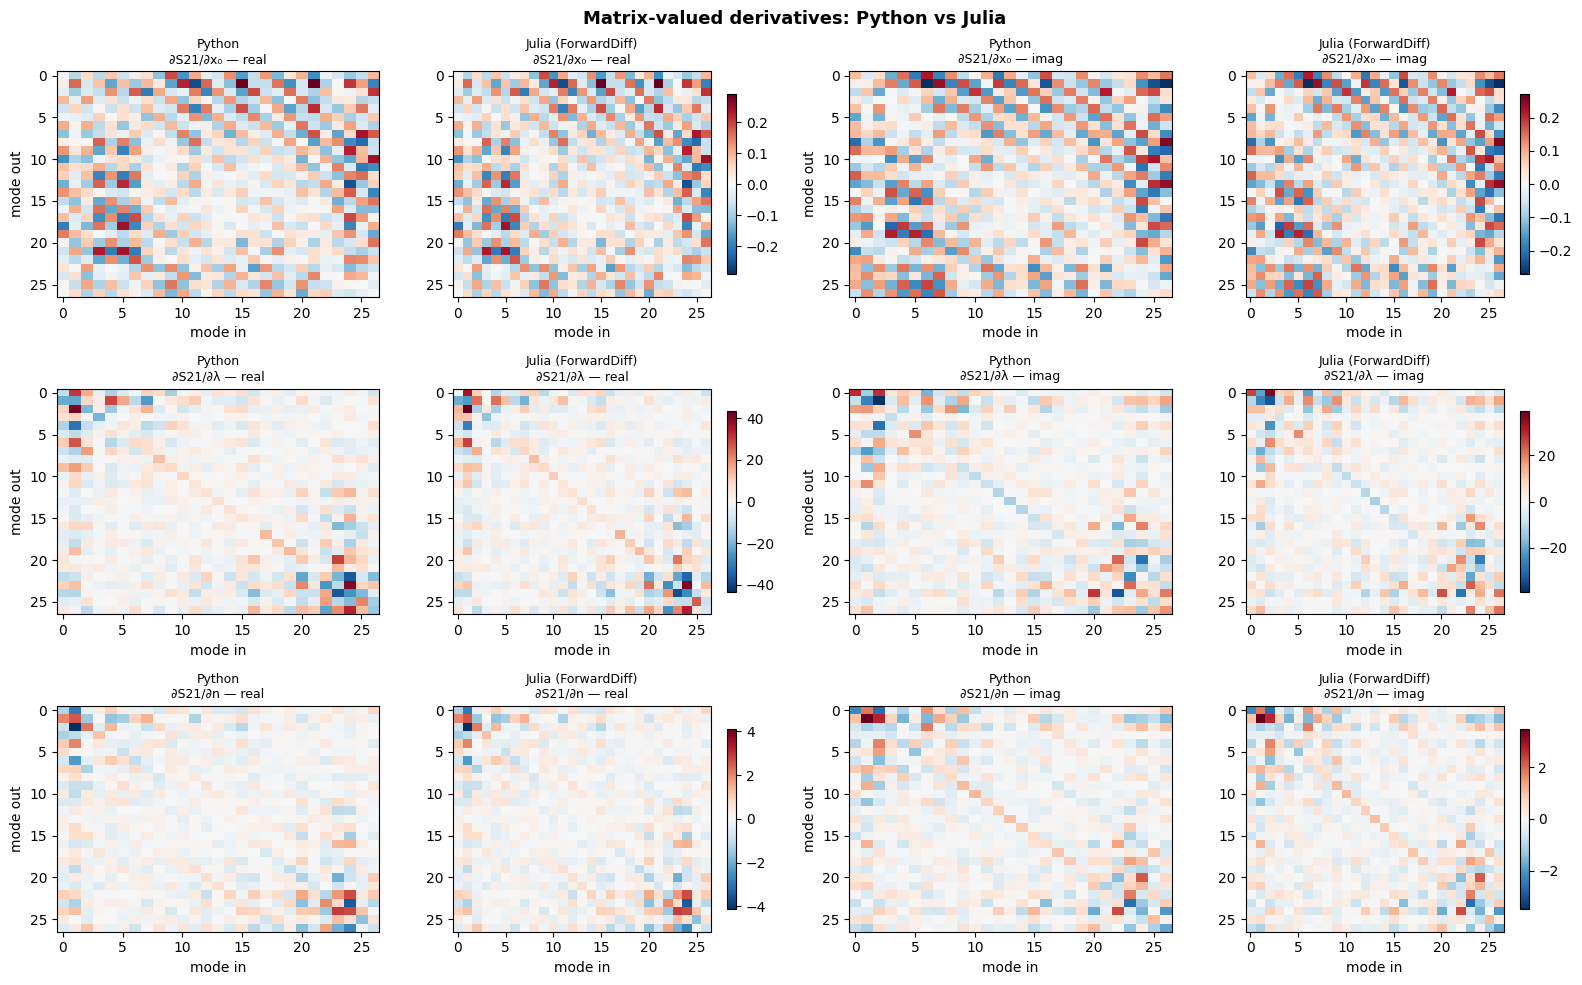

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
pairs = [
    ("∂S21/∂x₀ — real", dS21_dx0_py.real, dS21_dx0_jl.real),
    ("∂S21/∂x₀ — imag", dS21_dx0_py.imag, dS21_dx0_jl.imag),
    ("∂S21/∂λ — real",  dS21_dlam_py.real, dS21_dlam_jl.real),
    ("∂S21/∂λ — imag",  dS21_dlam_py.imag, dS21_dlam_jl.imag),
    ("∂S21/∂n — real",  dS21_dn_py.real,  dS21_dn_jl.real),
    ("∂S21/∂n — imag",  dS21_dn_py.imag,  dS21_dn_jl.imag),
]

for row, (title_py, A, B) in enumerate(pairs):
    col_base = (row % 3) * 0   # all in same row grouping
    r = row // 2
    c = (row % 2) * 2
    
    vmax = max(np.abs(A).max(), np.abs(B).max()) + 1e-12
    kw   = dict(cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    
    ax_py  = axes[r, c]
    ax_jl  = axes[r, c+1]
    
    ax_py.imshow(A, **kw)
    ax_py.set_title(f"Python\n{title_py}", fontsize=9)
    ax_py.set_xlabel("mode in"); ax_py.set_ylabel("mode out")
    
    im = ax_jl.imshow(B, **kw)
    ax_jl.set_title(f"Julia (ForwardDiff)\n{title_py}", fontsize=9)
    ax_jl.set_xlabel("mode in")
    plt.colorbar(im, ax=ax_jl, shrink=0.8)

plt.suptitle("Matrix-valued derivatives: Python vs Julia", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('derivative_comparison.png', dpi=150)
plt.show()


## 7. Absolute Difference (Python − Julia)

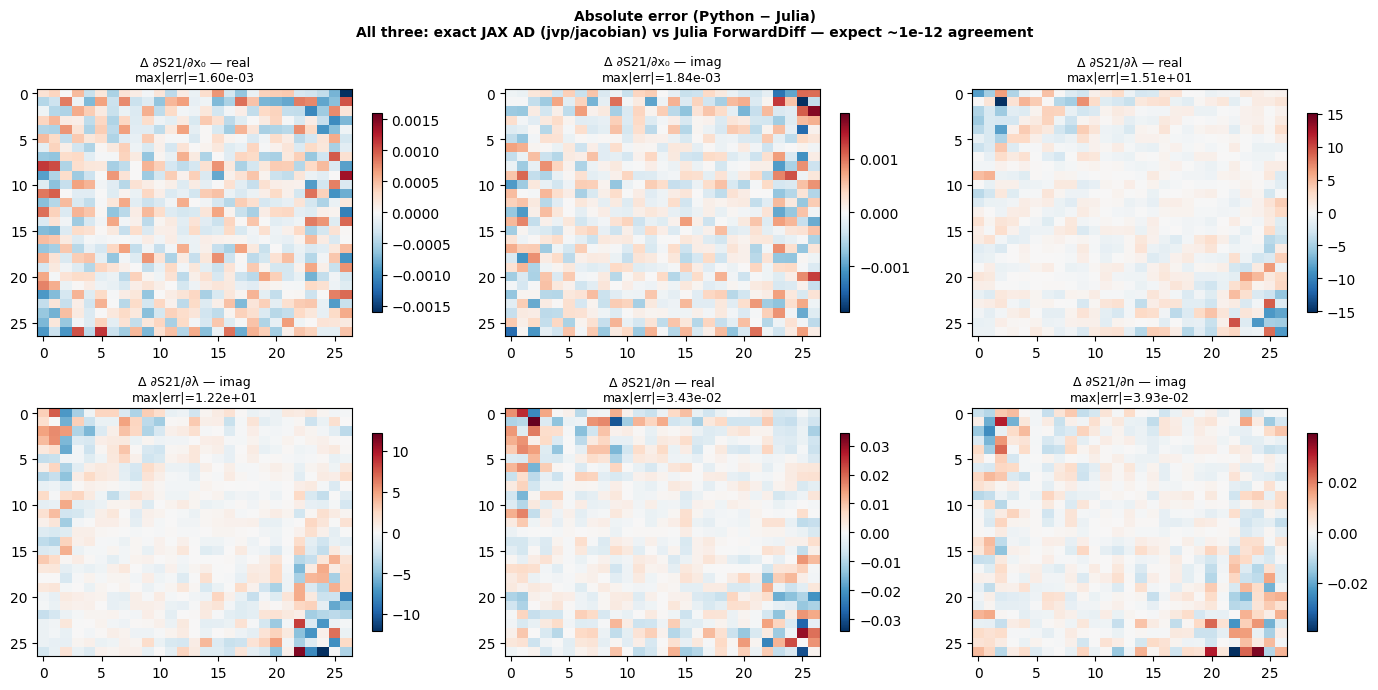

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
pairs_err = [
    ("∂S21/∂x₀ — real", dS21_dx0_py.real  - dS21_dx0_jl.real),
    ("∂S21/∂x₀ — imag", dS21_dx0_py.imag  - dS21_dx0_jl.imag),
    ("∂S21/∂λ — real",  dS21_dlam_py.real - dS21_dlam_jl.real),
    ("∂S21/∂λ — imag",  dS21_dlam_py.imag - dS21_dlam_jl.imag),
    ("∂S21/∂n — real",  dS21_dn_py.real   - dS21_dn_jl.real),
    ("∂S21/∂n — imag",  dS21_dn_py.imag   - dS21_dn_jl.imag),
]
for ax, (title, diff) in zip(axes.ravel(), pairs_err):
    vmax = np.abs(diff).max() + 1e-15
    im   = ax.imshow(diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_title(f"Δ {title}\nmax|err|={np.abs(diff).max():.2e}", fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("Absolute error (Python − Julia)\n"
             "All three: exact JAX AD (jvp/jacobian) vs Julia ForwardDiff — expect ~1e-12 agreement",
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('derivative_error.png', dpi=150)
plt.show()

